# Positions — Multi-Catalog Smoke Test

Three Iceberg tables in the `positions` schema of the `prod` catalog:

| Table | Key columns | Extra |
|---|---|---|
| `model_desired_positions` | trade_day, market, contract, portfolio, component | — |
| `rtm_positions` | trade_day, market, contract, portfolio | — |
| `expected_positions` | trade_day, market, contract, portfolio | — |

**Markets:** CL (Crude Oil), NG (Natural Gas), GC (Gold), ZC (Corn), ZS (Soybeans)  
**Models / components:** ModelA (trend-following), ModelB (mean-reverting), ModelC (seasonal)  
**Portfolios:** PortA, PortB, PortC  
**Date range:** Jan 2004 to present (monthly, month-end)

`expected_positions` = sum of all model signals + RTM offset per (trade_day, market, contract, portfolio).

In [1]:
%pip install trino pandas numpy matplotlib --quiet


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 1. Connect to Trino

In [1]:
import trino
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
from datetime import date

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (16, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

TRINO_HOST = "localhost"
TRINO_PORT = 8080
CATALOG    = "prod"
S3_BUCKET  = "shared-lake-bucket"  # CATALOG_prod_BUCKET in env/rsch-lake.mk
SCHEMA     = "positions"

conn = trino.dbapi.connect(
    host=TRINO_HOST, port=TRINO_PORT,
    user="admin", catalog=CATALOG, schema=SCHEMA,
    http_scheme="http",
)

def q(sql, fetch=True):
    cur = conn.cursor()
    cur.execute(sql)
    if fetch:
        cols = [d[0] for d in cur.description]
        return pd.DataFrame(cur.fetchall(), columns=cols)
    cur.fetchall()
    return None

print("Trino", q("SELECT version()").iloc[0, 0], "— connected.")

Trino 480 — connected.


## 2. Schema and Tables

In [2]:
q(f"""
    CREATE SCHEMA IF NOT EXISTS {CATALOG}.{SCHEMA}
    WITH (location = 's3://{S3_BUCKET}/{CATALOG}/{SCHEMA}/')
""", fetch=False)

q(f"""
    CREATE TABLE IF NOT EXISTS {CATALOG}.{SCHEMA}.model_desired_positions (
        trade_day  DATE           COMMENT 'Month-end trading date',
        market     VARCHAR        COMMENT 'Commodity market code',
        contract   INTEGER        COMMENT 'Front-month contract YYYYMM',
        portfolio  VARCHAR        COMMENT 'Portfolio name',
        component  VARCHAR        COMMENT 'Model / component name',
        position   DECIMAL(12, 4) COMMENT 'Desired position in lots'
    )
    WITH (format = 'PARQUET', partitioning = ARRAY['market', 'portfolio'])
""", fetch=False)

q(f"""
    CREATE TABLE IF NOT EXISTS {CATALOG}.{SCHEMA}.rtm_positions (
        trade_day  DATE           COMMENT 'Month-end trading date',
        market     VARCHAR        COMMENT 'Commodity market code',
        contract   INTEGER        COMMENT 'Front-month contract YYYYMM',
        portfolio  VARCHAR        COMMENT 'Portfolio name',
        position   DECIMAL(12, 4) COMMENT 'RTM offsetting position in lots'
    )
    WITH (format = 'PARQUET', partitioning = ARRAY['market', 'portfolio'])
""", fetch=False)

q(f"""
    CREATE TABLE IF NOT EXISTS {CATALOG}.{SCHEMA}.expected_positions (
        trade_day  DATE           COMMENT 'Month-end trading date',
        market     VARCHAR        COMMENT 'Commodity market code',
        contract   INTEGER        COMMENT 'Front-month contract YYYYMM',
        portfolio  VARCHAR        COMMENT 'Portfolio name',
        position   DECIMAL(12, 4) COMMENT 'Net expected position = model signals + RTM'
    )
    WITH (format = 'PARQUET', partitioning = ARRAY['market', 'portfolio'])
""", fetch=False)

print("Schema and tables ready.")
q(f"SHOW TABLES IN {CATALOG}.{SCHEMA}")

Schema and tables ready.


,Table
0,expected_positions
1,model_desired_positions
2,rtm_positions


## 3. Generate Sample Data

Positions follow **AR(1) processes** calibrated per model:
- **ModelA** (φ = 0.95): slow-moving trend signal
- **ModelB** (φ = 0.80): faster mean-reverting signal
- **ModelC** (φ = 0.88 + seasonal): annual commodity cycle

RTM positions offset 5–20% of the net model signal with small random noise.

In [3]:
np.random.seed(42)

MARKETS = {
    "CL": 30,   # Crude Oil     — position scale (lots)
    "NG": 60,   # Natural Gas
    "GC": 12,   # Gold
    "ZC": 120,  # Corn
    "ZS": 90,   # Soybeans
}
MODELS     = ["ModelA", "ModelB", "ModelC"]
PORTFOLIOS = ["PortA",  "PortB",  "PortC"]

MODEL_PARAMS = {
    "ModelA": {"phi": 0.95, "seasonal": 0.0},
    "ModelB": {"phi": 0.80, "seasonal": 0.0},
    "ModelC": {"phi": 0.88, "seasonal": 1.0},
}

dates = pd.date_range("2004-01-31", pd.Timestamp.today(), freq="ME")
n     = len(dates)

def ar1(n, phi, sigma, seasonal_amp=0.0):
    x = np.zeros(n)
    for t in range(1, n):
        x[t] = phi * x[t - 1] + sigma * np.random.randn() + seasonal_amp * np.sin(2 * np.pi * t / 12)
    return np.round(x).astype(int)

# --- model_desired_positions ---
mdp_rows = []
for mkt, scale in MARKETS.items():
    for port in PORTFOLIOS:
        for model in MODELS:
            p   = MODEL_PARAMS[model]
            pos = ar1(n, p["phi"], scale * 0.2, scale * 0.3 * p["seasonal"])
            for i, dt in enumerate(dates):
                mdp_rows.append({
                    "trade_day": dt.date(),
                    "market":    mkt,
                    "contract":  dt.year * 100 + dt.month,
                    "portfolio": port,
                    "component": model,
                    "position":  int(pos[i]),
                })

mdp_df = pd.DataFrame(mdp_rows)

# --- rtm_positions (5–20% offsetting the net model signal, vectorised) ---
model_net = (
    mdp_df
    .groupby(["trade_day", "market", "contract", "portfolio"], as_index=False, sort=False)["position"]
    .sum()
    .rename(columns={"position": "model_net"})
)

n_rtm = len(model_net)
frac  = np.random.uniform(0.05, 0.20, size=n_rtm)
noise = np.random.randint(-2, 3,       size=n_rtm)

rtm_df = model_net.copy()
rtm_df["position"] = ((-model_net["model_net"].values * frac).round() + noise).astype(int)
rtm_df = rtm_df.drop(columns=["model_net"])

# --- expected_positions = net model signal + RTM ---
exp_df = model_net.rename(columns={"model_net": "position"}).copy()
exp_df["position"] = exp_df["position"].values + rtm_df["position"].values

print(f"model_desired_positions : {len(mdp_df):>7,} rows  ({mdp_df['trade_day'].min()} to {mdp_df['trade_day'].max()})")
print(f"rtm_positions           : {len(rtm_df):>7,} rows")
print(f"expected_positions      : {len(exp_df):>7,} rows")
mdp_df.head(6)

model_desired_positions :  12,105 rows  (2004-01-31 to 2026-05-31)
rtm_positions           :   4,035 rows
expected_positions      :   4,035 rows


,trade_day,market,contract,portfolio,component,position
0,2004-01-31,CL,200401,PortA,ModelA,0
1,2004-02-29,CL,200402,PortA,ModelA,3
2,2004-03-31,CL,200403,PortA,ModelA,2
3,2004-04-30,CL,200404,PortA,ModelA,6
4,2004-05-31,CL,200405,PortA,ModelA,15
5,2004-06-30,CL,200406,PortA,ModelA,12


## 4. Load Data into Trino / Iceberg

In [ ]:
# Uncomment to wipe tables before reloading (full refresh)
# for tbl in ["model_desired_positions", "rtm_positions", "expected_positions"]:
#     q(f"DELETE FROM {CATALOG}.{SCHEMA}.{tbl}", fetch=False)
#     print(f"Cleared {tbl}")

In [4]:
def upsert_df(df, table, key_cols, batch_size=200):
    """Batch-upsert a DataFrame into a Trino/Iceberg table via MERGE INTO."""
    all_cols = list(df.columns)
    val_cols = [c for c in all_cols if c not in key_cols]
    cur = conn.cursor()
    total, done = len(df), 0

    for start in range(0, total, batch_size):
        batch = df.iloc[start : start + batch_size]
        values_parts = []
        for r in batch.itertuples(index=False):
            parts = []
            for col in all_cols:
                v = getattr(r, col)
                if isinstance(v, (date, pd.Timestamp)):
                    parts.append(f"DATE '{v}'")
                elif isinstance(v, str):
                    parts.append(f"'{v}'")
                elif col == "position":
                    parts.append(f"DECIMAL '{int(v)}'")
                else:
                    parts.append(str(int(v)))
            values_parts.append(f"({', '.join(parts)})")

        values_str = ", ".join(values_parts)
        cols_str   = ", ".join(all_cols)
        on_clause  = " AND ".join(f"t.{c} = s.{c}" for c in key_cols)
        upd_set    = ", ".join(f"{c} = s.{c}" for c in val_cols)
        ins_vals   = ", ".join(f"s.{c}" for c in all_cols)

        cur.execute(f"""
            MERGE INTO {table} AS t
            USING (SELECT * FROM (VALUES {values_str}) AS v({cols_str})) AS s
            ON {on_clause}
            WHEN MATCHED THEN UPDATE SET {upd_set}
            WHEN NOT MATCHED THEN INSERT ({cols_str}) VALUES ({ins_vals})
        """)
        cur.fetchall()
        done += len(batch)
        print(f"  {done:>6}/{total}", end="\r")

    print(f"  {done:>6}/{total} — done.")
    return done

MDP = f"{CATALOG}.{SCHEMA}.model_desired_positions"
RTM = f"{CATALOG}.{SCHEMA}.rtm_positions"
EXP = f"{CATALOG}.{SCHEMA}.expected_positions"

MDP_KEYS = ["trade_day", "market", "contract", "portfolio", "component"]
RTM_KEYS = ["trade_day", "market", "contract", "portfolio"]
EXP_KEYS = ["trade_day", "market", "contract", "portfolio"]

print(f"Loading model_desired_positions  ({len(mdp_df):,} rows)...")
upsert_df(mdp_df, MDP, MDP_KEYS)

print(f"\nLoading rtm_positions            ({len(rtm_df):,} rows)...")
upsert_df(rtm_df, RTM, RTM_KEYS)

print(f"\nLoading expected_positions       ({len(exp_df):,} rows)...")
upsert_df(exp_df, EXP, EXP_KEYS)

print("\nAll tables loaded.")

Loading model_desired_positions  (12,105 rows)...
   12105/12105 — done.

Loading rtm_positions            (4,035 rows)...
    4035/4035 — done.

Loading expected_positions       (4,035 rows)...
    4035/4035 — done.

All tables loaded.


## 5. Verify

In [5]:
counts = q(f"""
    SELECT 'model_desired_positions' AS tbl, COUNT(*) AS rows, MIN(trade_day) AS first, MAX(trade_day) AS last FROM {MDP}
    UNION ALL
    SELECT 'rtm_positions',                  COUNT(*),         MIN(trade_day),           MAX(trade_day)           FROM {RTM}
    UNION ALL
    SELECT 'expected_positions',             COUNT(*),         MIN(trade_day),           MAX(trade_day)           FROM {EXP}
""")
print(counts.to_string(index=False))

                    tbl  rows      first       last
     expected_positions  4035 2004-01-31 2026-05-31
          rtm_positions  4035 2004-01-31 2026-05-31
model_desired_positions 12105 2004-01-31 2026-05-31


In [7]:
# Latest month: desired position by model for each market / portfolio
latest = q(f"""
    SELECT
        market,
        portfolio,
        ROUND(CAST(SUM(CASE WHEN component = 'ModelA' THEN position ELSE 0 END) AS DOUBLE), 0) AS model_a,
        ROUND(CAST(SUM(CASE WHEN component = 'ModelB' THEN position ELSE 0 END) AS DOUBLE), 0) AS model_b,
        ROUND(CAST(SUM(CASE WHEN component = 'ModelC' THEN position ELSE 0 END) AS DOUBLE), 0) AS model_c,
        ROUND(CAST(SUM(position) AS DOUBLE), 0)                                                AS net_model
    FROM {MDP}
    WHERE trade_day = (SELECT MAX(trade_day) FROM {MDP})
    GROUP BY market, portfolio
    ORDER BY market, portfolio
""")
print(f"Latest month desired positions:")
latest

Latest month desired positions:


,market,portfolio,model_a,model_b,model_c,net_model
0,CL,PortA,-21.0,-15.0,16.0,-20.0
1,CL,PortB,-2.0,-1.0,14.0,11.0
2,CL,PortC,15.0,0.0,26.0,41.0
3,GC,PortA,0.0,-7.0,8.0,1.0
4,GC,PortB,-18.0,-7.0,1.0,-24.0
5,GC,PortC,-7.0,1.0,11.0,5.0
6,NG,PortA,-47.0,-41.0,92.0,4.0
7,NG,PortB,-45.0,-16.0,2.0,-59.0
8,NG,PortC,-24.0,3.0,14.0,-7.0
9,ZC,PortA,-2.0,51.0,86.0,135.0


In [8]:
# Latest month: model net vs RTM vs expected
compare = q(f"""
    SELECT
        m.market,
        m.portfolio,
        ROUND(CAST(m.position AS DOUBLE), 0)                                                  AS model_net,
        ROUND(CAST(r.position AS DOUBLE), 0)                                                  AS rtm,
        ROUND(CAST(e.position AS DOUBLE), 0)                                                  AS expected,
        ROUND(CAST(r.position AS DOUBLE) / NULLIF(CAST(m.position AS DOUBLE), 0) * 100, 1)   AS rtm_pct
    FROM (
        SELECT market, portfolio, SUM(position) AS position
        FROM {MDP}
        WHERE trade_day = (SELECT MAX(trade_day) FROM {MDP})
        GROUP BY market, portfolio
    ) m
    JOIN {RTM} r
        ON  r.trade_day = (SELECT MAX(trade_day) FROM {RTM})
        AND r.market = m.market AND r.portfolio = m.portfolio
    JOIN {EXP} e
        ON  e.trade_day = (SELECT MAX(trade_day) FROM {EXP})
        AND e.market = m.market AND e.portfolio = m.portfolio
    ORDER BY m.market, m.portfolio
""")
print("Latest month — model net vs RTM vs expected:")
compare

Latest month — model net vs RTM vs expected:


,market,portfolio,model_net,rtm,expected,rtm_pct
0,CL,PortA,-20.0,4.0,-16.0,-20.0
1,CL,PortB,11.0,-4.0,7.0,-36.4
2,CL,PortC,41.0,-1.0,40.0,-2.4
3,GC,PortA,1.0,1.0,2.0,100.0
4,GC,PortB,-24.0,4.0,-20.0,-16.7
5,GC,PortC,5.0,-2.0,3.0,-40.0
6,NG,PortA,4.0,0.0,4.0,0.0
7,NG,PortB,-59.0,10.0,-49.0,-16.9
8,NG,PortC,-7.0,0.0,-7.0,0.0
9,ZC,PortA,135.0,-22.0,113.0,-16.3


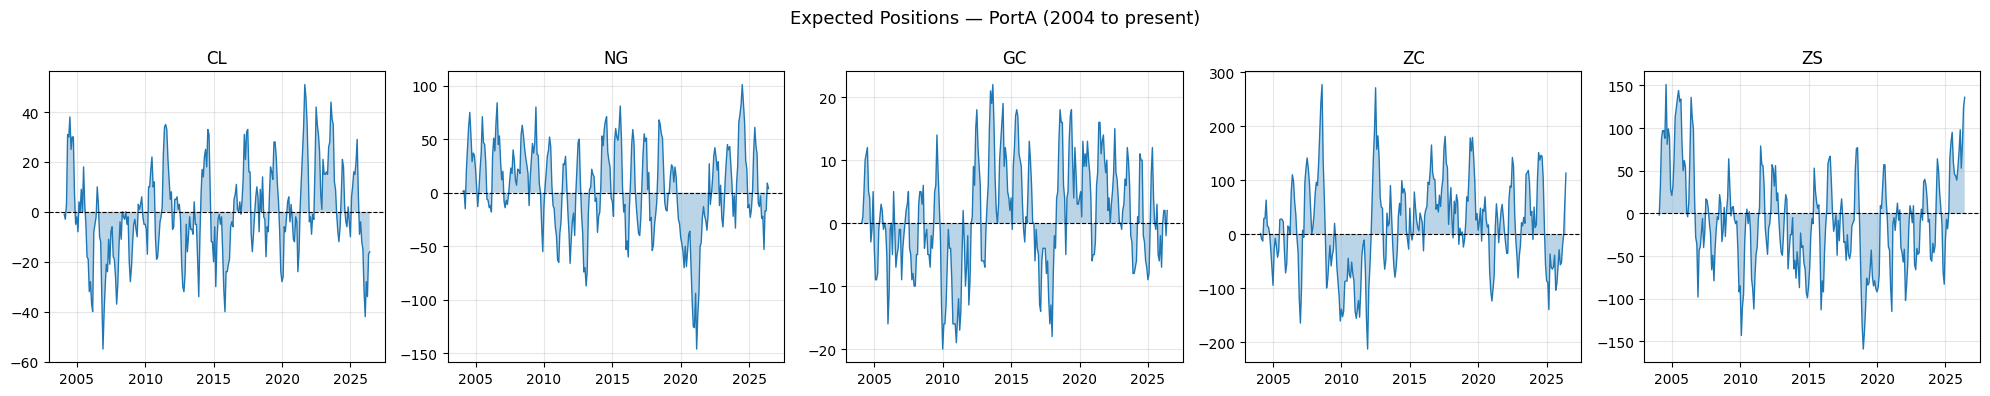

In [8]:
# Expected position history for PortA — all markets
history = q(f"""
    SELECT trade_day, market, CAST(position AS DOUBLE) AS position
    FROM {EXP}
    WHERE portfolio = 'PortA'
    ORDER BY market, trade_day
""")
history["trade_day"] = pd.to_datetime(history["trade_day"])

fig, axes = plt.subplots(1, 5, figsize=(20, 4), tight_layout=True)
fig.suptitle("Expected Positions — PortA (2004 to present)", fontsize=13)

for ax, mkt in zip(axes, list(MARKETS.keys())):
    sub = history[history["market"] == mkt]
    ax.fill_between(sub["trade_day"], sub["position"], alpha=0.3)
    ax.plot(sub["trade_day"], sub["position"], lw=1)
    ax.axhline(0, color="black", lw=0.8, ls="--")
    ax.set_title(mkt)
    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.show()

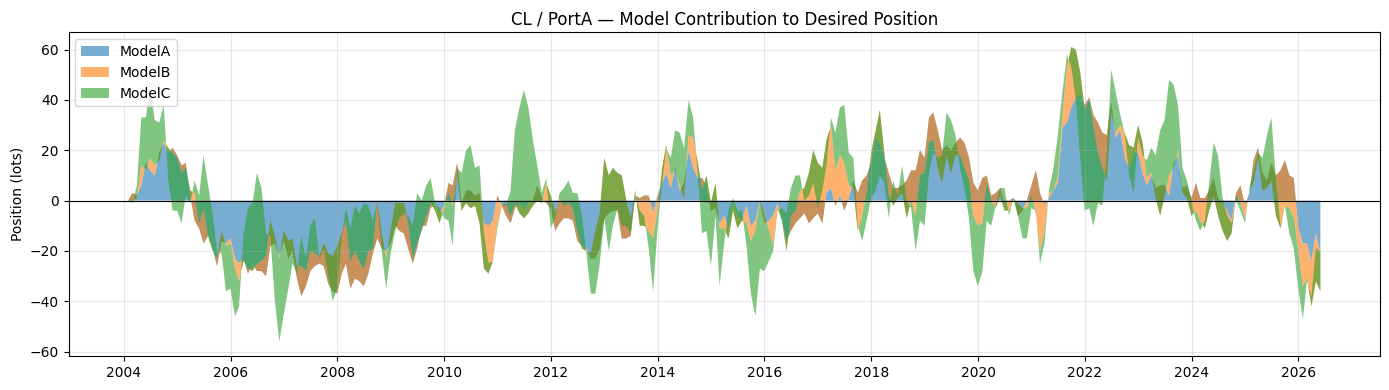

In [10]:
# Model contribution over time — stacked area chart for CL / PortA
contrib = q(f"""
    SELECT
        trade_day,
        CAST(SUM(CASE WHEN component = 'ModelA' THEN position ELSE 0 END) AS DOUBLE) AS model_a,
        CAST(SUM(CASE WHEN component = 'ModelB' THEN position ELSE 0 END) AS DOUBLE) AS model_b,
        CAST(SUM(CASE WHEN component = 'ModelC' THEN position ELSE 0 END) AS DOUBLE) AS model_c
    FROM {MDP}
    WHERE market = 'CL' AND portfolio = 'PortA'
    GROUP BY trade_day
    ORDER BY trade_day
""")
contrib["trade_day"] = pd.to_datetime(contrib["trade_day"])

fig, ax = plt.subplots(figsize=(14, 4), tight_layout=True)
ax.stackplot(
    contrib["trade_day"],
    contrib["model_a"], contrib["model_b"], contrib["model_c"],
    labels=["ModelA", "ModelB", "ModelC"],
    alpha=0.6,
)
ax.axhline(0, color="black", lw=0.8)
ax.set_title("CL / PortA — Model Contribution to Desired Position")
ax.set_ylabel("Position (lots)")
ax.legend(loc="upper left")
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.show()

In [11]:
# Iceberg snapshot metadata
snaps = q(f"""
    SELECT
        snapshot_id,
        committed_at,
        operation,
        element_at(summary, 'added-records')    AS added,
        element_at(summary, 'total-records')    AS total
    FROM {CATALOG}.{SCHEMA}."model_desired_positions$snapshots"
    ORDER BY committed_at
""")
print(f"{len(snaps)} snapshot(s) on model_desired_positions:")
snaps

62 snapshot(s) on model_desired_positions:


,snapshot_id,committed_at,operation,added,total
0,4660733353911218812,2026-06-08 22:31:24.471000-04:00,append,NaN,0
1,5384148883084201348,2026-06-08 22:31:41.042000-04:00,overwrite,200,200
2,4485846772914384362,2026-06-08 22:31:42.315000-04:00,overwrite,200,400
3,8909069858844694893,2026-06-08 22:31:43.336000-04:00,overwrite,200,600
4,4926827645270711635,2026-06-08 22:31:44.320000-04:00,overwrite,200,800
...,...,...,...,...,...
57,9057552288929568092,2026-06-08 22:32:28.897000-04:00,overwrite,200,11400
58,7314574098148357707,2026-06-08 22:32:29.790000-04:00,overwrite,200,11600
59,8817954534700320030,2026-06-08 22:32:30.520000-04:00,overwrite,200,11800
60,6283383698131617994,2026-06-08 22:32:31.117000-04:00,overwrite,200,12000


In [ ]:
# Uncomment to clean up
# for tbl in ["model_desired_positions", "rtm_positions", "expected_positions"]:
#     q(f"DROP TABLE IF EXISTS {CATALOG}.{SCHEMA}.{tbl}", fetch=False)
# q(f"DROP SCHEMA IF EXISTS {CATALOG}.{SCHEMA}", fetch=False)
# print("Cleaned up.")